# 03 — Feature Engineering (+ Sentiment)

Purpose: run `feature_engineering.py` and `sentiment.py`'s functions
step by step, plot the resulting technical indicators and sentiment
scores for a sample ticker, and confirm the forward-looking risk label
distribution looks reasonable before it's used for ML training.

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import yaml
from pyspark.sql import functions as F
from src.etl.spark_session import get_spark_session, s3a_path
from src.etl.feature_engineering import (
    add_returns, add_rolling_volatility, add_moving_averages,
    add_rsi, add_macd, add_forward_volatility_label,
)
from src.etl.sentiment import add_sentiment_scores

with open("../config/config.yaml") as f:
    config = yaml.safe_load(f)

spark = get_spark_session(
    app_name=config["spark"]["app_name"] + "-FeatureNotebook",
    master=config["spark"]["master"],
)

bucket = config["s3"]["bucket"]
in_path = s3a_path(bucket, config["s3"]["paths"]["processed_base"])
df = spark.read.parquet(in_path)
df.printSchema()


## 1. Returns + rolling volatility


In [2]:
fe_config = config["feature_engineering"]

df = add_returns(df)
df = add_rolling_volatility(df, fe_config["rolling_windows_days"])
df = add_moving_averages(df, fe_config["rolling_windows_days"])
df.select("ticker", "date", "close", "daily_return", "volatility_20d", "ma_20d").show(10)

+------+----------+------------------+--------------------+--------------------+------------------+
|ticker|      date|             close|        daily_return|      volatility_20d|            ma_20d|
+------+----------+------------------+--------------------+--------------------+------------------+
|360ONE|2021-07-26|288.59600830078125|                NULL|                NULL|288.59600830078125|
|360ONE|2021-07-27| 285.5711975097656|-0.01048112483892...|                NULL|287.08360290527344|
|360ONE|2021-07-28| 284.8149719238281|-0.00264811575022...|0.005538773843711739|  286.327392578125|
|360ONE|2021-07-29|  284.135498046875|-0.00238566769283...|0.004600024216795631| 285.7794189453125|
|360ONE|2021-07-30| 309.3423156738281| 0.08871407409571419| 0.04709287058200251|290.49199829101565|
|360ONE|2021-08-02| 313.9891052246094|0.015021512788055951| 0.04080996528963852|294.40818277994794|
|360ONE|2021-08-03|303.31463623046875|-0.03399630374596...|0.042152324312336634| 295.6805332728795|


## 2. Technical indicators: RSI, MACD

In [3]:
df = add_rsi(df)
df = add_macd(df)
df.select("ticker", "date", "rsi_14", "macd_line", "macd_signal").show(10)

+------+----------+-----------------+---------+-----------+
|ticker|      date|           rsi_14|macd_line|macd_signal|
+------+----------+-----------------+---------+-----------+
|360ONE|2021-07-26|            100.0|      0.0|        0.0|
|360ONE|2021-07-27|              0.0|      0.0|        0.0|
|360ONE|2021-07-28|              0.0|      0.0|        0.0|
|360ONE|2021-07-29|              0.0|      0.0|        0.0|
|360ONE|2021-07-30| 85.1145929586436|      0.0|        0.0|
|360ONE|2021-08-02|86.98964875540449|      0.0|        0.0|
|360ONE|2021-08-03| 67.6918458463376|      0.0|        0.0|
|360ONE|2021-08-04|83.60379919059804|      0.0|        0.0|
|360ONE|2021-08-05|75.13551709159772|      0.0|        0.0|
|360ONE|2021-08-06|78.91395463272941|      0.0|        0.0|
+------+----------+-----------------+---------+-----------+
only showing top 10 rows



## 3. Sentiment scoring

In [4]:
df = add_sentiment_scores(df)
df.select("ticker", "date", "article_count", "daily_sentiment", "sentiment_3d_avg").show(10)

+------+----------+-------------+---------------+----------------+
|ticker|      date|article_count|daily_sentiment|sentiment_3d_avg|
+------+----------+-------------+---------------+----------------+
|360ONE|2021-07-26|            0|            0.0|             0.0|
|360ONE|2021-07-27|            0|            0.0|             0.0|
|360ONE|2021-07-28|            0|            0.0|             0.0|
|360ONE|2021-07-29|            0|            0.0|             0.0|
|360ONE|2021-07-30|            0|            0.0|             0.0|
|360ONE|2021-08-02|            0|            0.0|             0.0|
|360ONE|2021-08-03|            0|            0.0|             0.0|
|360ONE|2021-08-04|            0|            0.0|             0.0|
|360ONE|2021-08-05|            0|            0.0|             0.0|
|360ONE|2021-08-06|            0|            0.0|             0.0|
+------+----------+-------------+---------------+----------------+
only showing top 10 rows



## 4. Forward-looking risk label

In [ ]:
ml_config = config["ml"]["risk_label"]
df = add_forward_volatility_label(
    df, ml_config["horizon_days"], ml_config["buckets"], config["ml"]["train_test_split"]
)
df.groupBy("risk_label").count().show()

Check the class balance above -- if one bucket dominates heavily, consider
adjusting `ml.risk_label.horizon_days` in config.yaml or moving from equal
quantile buckets to fixed volatility thresholds before training.


## 5. Visual inspection for one sample ticker


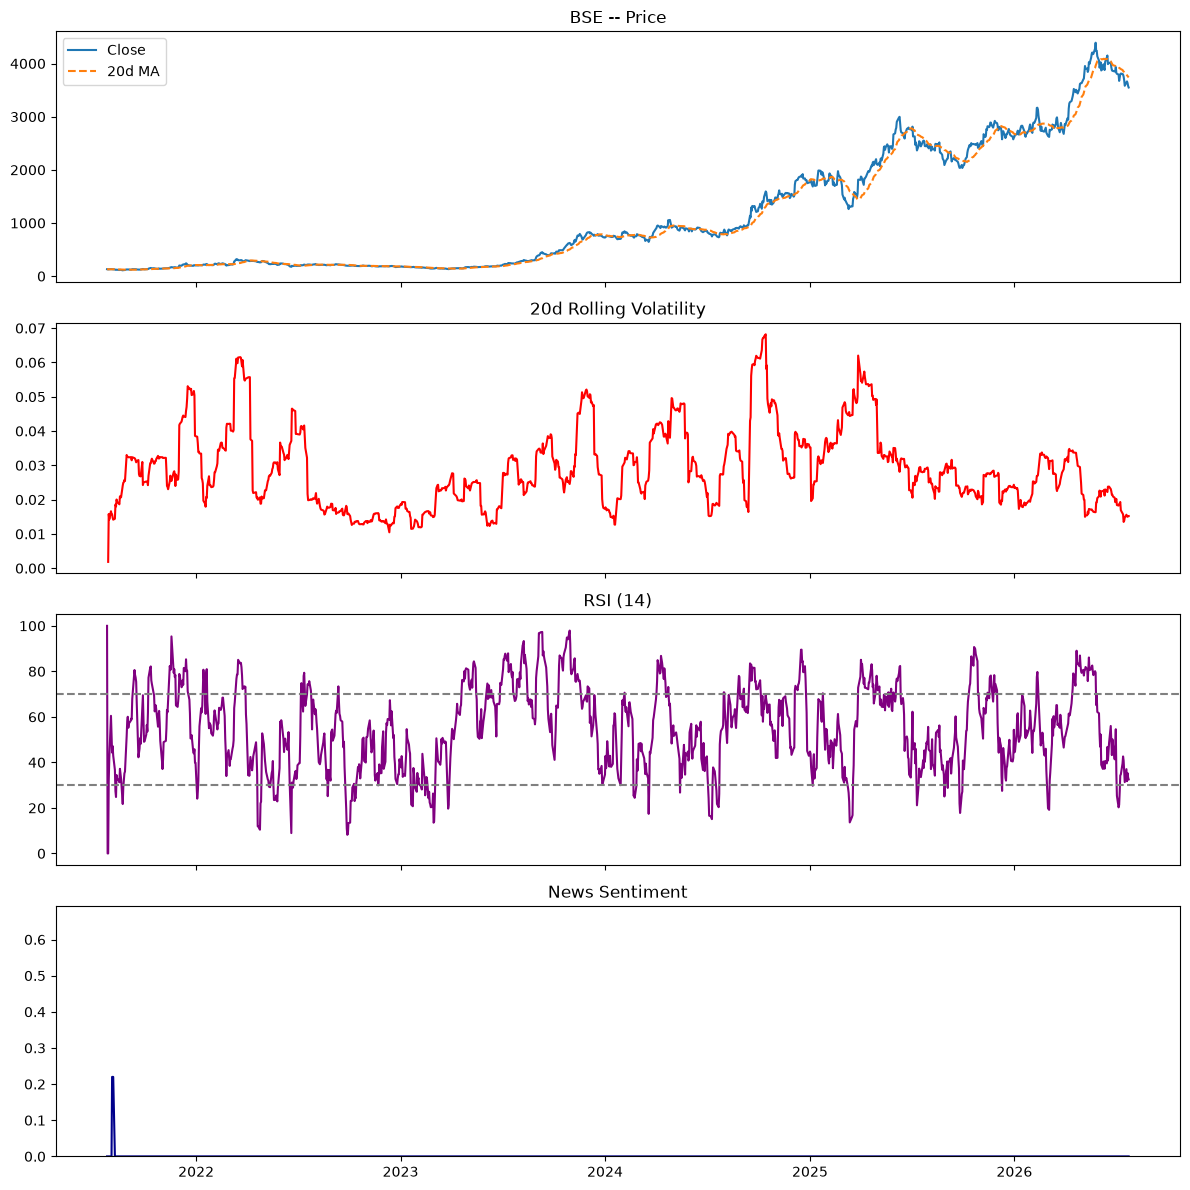

In [6]:
sample_ticker = df.select("ticker").first()[0]
sample_pd = df.filter(df.ticker == sample_ticker).orderBy("date").toPandas()

import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axes[0].plot(sample_pd["date"], sample_pd["close"], label="Close")
axes[0].plot(sample_pd["date"], sample_pd["ma_20d"], label="20d MA", linestyle="--")
axes[0].set_title(f"{sample_ticker} -- Price")
axes[0].legend()

axes[1].plot(sample_pd["date"], sample_pd["volatility_20d"], color="red")
axes[1].set_title("20d Rolling Volatility")

axes[2].plot(sample_pd["date"], sample_pd["rsi_14"], color="purple")
axes[2].axhline(70, linestyle="--", color="gray")
axes[2].axhline(30, linestyle="--", color="gray")
axes[2].set_title("RSI (14)")

axes[3].bar(sample_pd["date"], sample_pd["daily_sentiment"], color="gray", alpha=0.5)
axes[3].plot(sample_pd["date"], sample_pd["sentiment_3d_avg"], color="darkblue")
axes[3].set_title("News Sentiment")

plt.tight_layout()
plt.show()

## 6. Write out (optional)

Only run if you're deliberately overwriting the feature table from this
notebook rather than via the production pipeline.

In [7]:
# df.write.mode("overwrite").partitionBy("ticker").parquet(in_path)

In [8]:
spark.stop()